In [ ]:
%load_ext autoreload
%autoreload 2
import os
import sys
sys.path.append(os.path.abspath('..'))
import utils

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [172]:
import pandas as pd
import numpy as np

In [7]:
#descargamos si no existen
utils.descarga("https://ignaciorlando.github.io/datasets/data-science/movies.csv", "movies.csv", "ej1")

No vamos a bajar el archivo porque ya existe


In [111]:
#leemos el archivo csv
df = pd.read_csv("movies.csv")

In [8]:
df.head()

,MOVIES,YEAR,GENRE,RATING,ONE-LINE,STARS,VOTES,RunTime,Gross
0,Blood Red Sky,(2021),"\nAction, Horror, Thriller",6.1,\nA woman with a mysterious illness is forced ...,\n Director:\nPeter Thorwarth\n| \n Star...,"21,062",121.0,NaN
1,Masters of the Universe: Revelation,(2021– ),"\nAnimation, Action, Adventure",5.0,\nThe war for Eternia begins again in what may...,"\n \n Stars:\nChris Wood, \nSara...","17,870",25.0,NaN
2,The Walking Dead,(2010–2022),"\nDrama, Horror, Thriller",8.2,\nSheriff Deputy Rick Grimes wakes up from a c...,"\n \n Stars:\nAndrew Lincoln, \n...","885,805",44.0,NaN
3,Rick and Morty,(2013– ),"\nAnimation, Adventure, Comedy",9.2,\nAn animated series that follows the exploits...,"\n \n Stars:\nJustin Roiland, \n...","414,849",23.0,NaN
4,Army of Thieves,(2021),"\nAction, Crime, Horror",NaN,"\nA prequel, set before the events of Army of ...",\n Director:\nMatthias Schweighöfer\n| \n ...,NaN,NaN,NaN


In [94]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9999 entries, 0 to 9998
Data columns (total 36 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MOVIES       9999 non-null   str    
 1   YEAR         9355 non-null   str    
 2   GENRE        9919 non-null   str    
 3   RATING       8179 non-null   float64
 4   ONE-LINE     8713 non-null   str    
 5   STARS        9999 non-null   str    
 6   VOTES        8179 non-null   str    
 7   RunTime      7041 non-null   float64
 8   Gross        460 non-null    str    
 9   Action       9999 non-null   int64  
 10  Adventure    9999 non-null   int64  
 11  Animation    9999 non-null   int64  
 12  Biography    9999 non-null   int64  
 13  Comedy       9999 non-null   int64  
 14  Crime        9999 non-null   int64  
 15  Documentary  9999 non-null   int64  
 16  Drama        9999 non-null   int64  
 17  Family       9999 non-null   int64  
 18  Fantasy      9999 non-null   int64  
 19  Film-Noir    9999

<p>Reemplazamos todas las columnas que tienen `Add a Plot` con nulo en ONE-LINE

In [35]:
df['ONE-LINE'].value_counts()

ONE-LINE
\nThe Buddis bounce, spin, glide - and giggle. - through their magical world, learning new things and sharing the joy of friendship.                          8
\nWith kindness, curiosity and childlike wonder, five best friends explore their colourful world and find the extraordinary in everyday things.               8
\nHome for Christmas is back to save the holidays. Find out who was behind the door.                                                                          6
\nA psychic middle school boy tries to live a normal life and keep his growing powers under control, even though he constantly gets into trouble.             2
\nA gambling prodigy comes to an elite school run by games and turns the order upside down.                                                                   2
                                                                                                                                                             ..
\nAfter getting an anonymous ti

In [58]:
print(df[df['ONE-LINE'].str.contains('unknown', case=False, na=False)]['ONE-LINE'])

197     \nIn Jumanji: The Next Level, the gang is back...
493     \nAn unlikely trio travel through time in orde...
541     \nA Marine travels to Louisiana after serving ...
735     \nThe rapid spread of an unknown infection has...
747     \nA father has a recurring dream of losing his...
1365    \nA man teaches a young woman how to become a ...
1969    \nIn this deliciously macabre horror anthology...
2217    \nThe extraordinary story of Earth and why it ...
2251    \nYotsuya Yuusuke along with his classmates Sh...
2345    \nEric comes to El Camino looking for his unkn...
2508    \nStory of Failed Gujarati Businessman, who ju...
2618    \nIn the lost holy land of Milos, the Elrics s...
2757    \nA precarious future where Earth is running o...
3283    \nThe mysterious disappearance of a young woma...
3359    \n15-year-old scientist Ashley Garcia explores...
3848    \nUnknown creatures. Deadly pitfalls. With so ...
4894    \nIn 2000, David Wain and Michael Showalter se...
5065    \nA sm

In [60]:
df['ONE-LINE'].isna().sum()

np.int64(1286)

In [112]:
df['ONE-LINE'] = df['ONE-LINE'].replace(['\nAdd a Plot\n', '\nPlot unknown.', '\nPlot under wraps.', '\nPlot kept under wraps.', ''], pd.NA)

In [113]:
df['ONE-LINE'] = df['ONE-LINE'].str.replace('\nPlot unknown. ', '', regex=False)
df['ONE-LINE'] = df['ONE-LINE'].str.replace('\nPlot Unknown, ', '', regex=False)
df['ONE-LINE'] = df['ONE-LINE'].str.replace('\nPlot Unknown. ', '', regex=False)
df['ONE-LINE'] = df['ONE-LINE'].str.replace('\nPlot Unknown.', '', regex=False)
df['ONE-LINE'] = df['ONE-LINE'].str.replace('\nThe plot is unknown', '', regex=False)

In [ ]:
for idx, val in df["ONE-LINE"].value_counts().items():
  print(idx, val)

In [190]:
df = pd.read_csv("movies.csv")

GENRE

In [ ]:
pre_df = df.copy()

pre_df.isna().sum()

In [ ]:
df['GENRE'].value_counts()


GENRE
\nComedy                                      852
\nAnimation, Action, Adventure                693
\nDrama                                       562
\nDocumentary                                 498
\nCrime, Drama, Mystery                       336
                                             ... 
\nDocumentary, Action, Crime                    1
\nShort, History                                1
\nShort, Reality-TV                             1
\nShort, Action                                 1
\nNews, Reality-TV                              1
Name: count, Length: 510, dtype: int64

In [192]:
print(df[df['GENRE'].str.contains('Unknown', case=False, na=False)]['GENRE'])
pre_df = df.copy()

Series([], Name: GENRE, dtype: str)


In [193]:
genre_clean = pre_df['GENRE'].str.strip()
genres_df = genre_clean.str.get_dummies(sep=', ')
pre_df = pre_df.join(genres_df)

In [ ]:
#print(pre_df)
pre_df.head()

La justificación que debes agregar en el cuaderno (Markdown)Para responder completamente la consigna, puedes agregar un texto explicativo (por ejemplo, en una celda de texto arriba o abajo de tu código) con los siguientes puntos de justificación:Justificación del mecanismo seleccionado:Naturaleza Multietiqueta: Una misma obra cinematográfica puede pertenecer a múltiples géneros simultáneamente (por ejemplo, Acción, Comedia y Drama).  Por qué One-Hot Encoding (str.get_dummies): Es el mejor mecanismo para conservar la estructura del dataset original (donde 1 fila representa 1 película). Permite evaluar la presencia de cada género como una variable binaria ($1$ o $0$) sin imponer un orden artificial entre ellos ni distorsionar la cardinalidad del conjunto.  Alternativa y su limitación (explode): Desanidar las listas con .explode() duplicaría las filas por cada género que tenga una película. Aunque explode() es útil para gráficos de frecuencia o agregaciones simples por género, altera la unidad de observación y provocaría sobreconteo en análisis estadísticos o en modelos de machine learning. Por eso, One-Hot Encoding es la mejor opción de preprocesamiento general.

<h3>Inciso E

<span style="color:orange">Existe el preconcepto de que las mejores películas según el público son las que han logrado mejores recaudaciones. ¿Qué podés decirnos de esta hipótesis, considerando los datos disponibles? Justificar.</span>

In [194]:
df = pre_df

In [195]:
df['RATING'].isna().sum()
pre_df['Gross'] = (
    df['Gross']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.replace('M', '', regex=False)
    .str.strip()
)

pre_df['Gross'] = pd.to_numeric(df['Gross'], errors='coerce')

df = pre_df
pre_dfdf = df.dropna(subset=['RATING', 'Gross'])


In [ ]:
df.info()

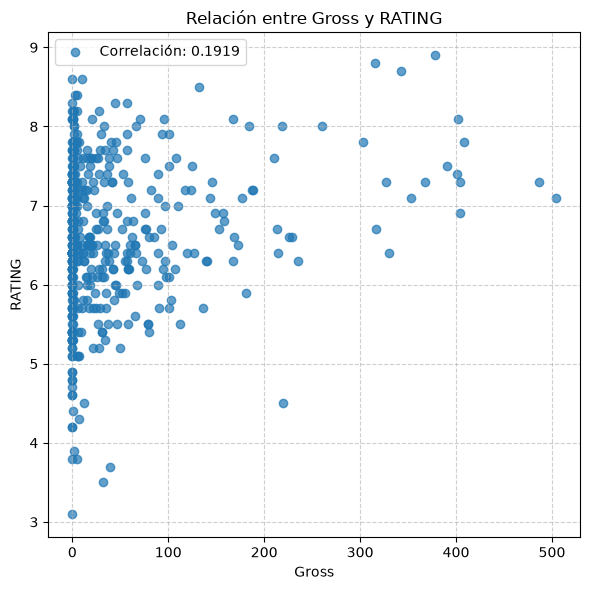

In [196]:
utils.scatter_plot('Gross', 'RATING', df)

<p>No hay argumentos suficientes para decir que las mejores peliculas son las que han logrado mejores recaudaciones.

<h3>Inciso f

In [200]:
pre_df_f = df

In [ ]:
pre_df_f.info()

In [ ]:
# pre_df_f['type'] = np.where (

#     pre_df_f['YEAR'].str.contains('–'),
#     'S',
#     'M'
# )
#pre_df_f = pre_df_f.dropna(subset=['RunTime', 'YEAR'])

In [204]:
from pyparsing import Regex

pre_df_f = pre_df_f.dropna(subset=['RunTime', 'YEAR'])
pre_df_f['YEAR_init'] = (
    pre_df_f['YEAR']
    .str.split('–')
    .str[0]
    .replace(r'\D', '', regex=True)
)

#lambda, USAR!!!!
pre_df_f['type'] = pre_df_f['YEAR'].apply(lambda x: 'S' if '–' in str(x) else 'M')

pre_df_f['YEAR_init'] = pd.to_numeric(pre_df_f['YEAR_init'])
#pre_df_f['YEAR_init'].value_counts()

In [ ]:
pre_df_f.head()

In [ ]:
pre_df_f.info()

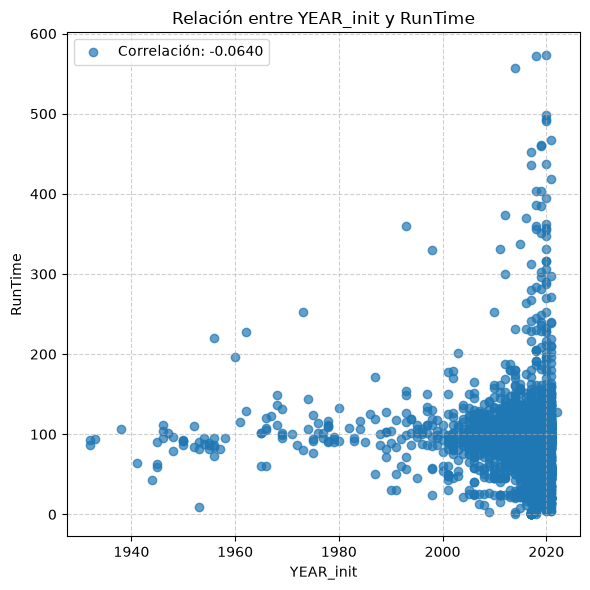

In [205]:
pre_pelis = pre_df_f[pre_df_f['type'] == 'M']
utils.scatter_plot('YEAR_init', 'RunTime', pre_pelis)

In [ ]:
median = pre_pelis[pre_pelis['YEAR_init'] == 2020]['RunTime'].median()
median

np.float64(90.0)

<Axes: >

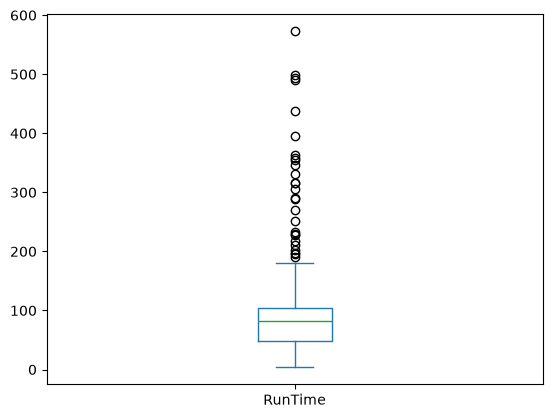

In [188]:
pre_pelis[pre_pelis['YEAR_init'] == 2020]['RunTime'].plot.box()

<p>Preguntar si estaba bien dividir entre peliculas y series

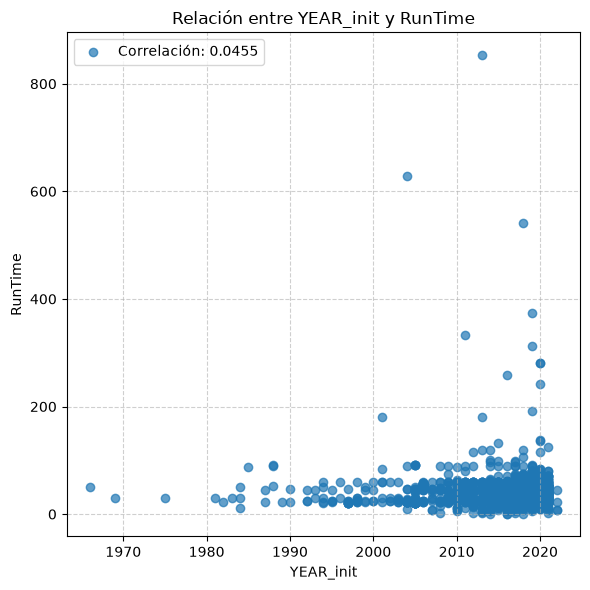

In [183]:
pre_series = pre_df_f[pre_df_f['type'] == 'S']
utils.scatter_plot('YEAR_init', 'RunTime', pre_series)

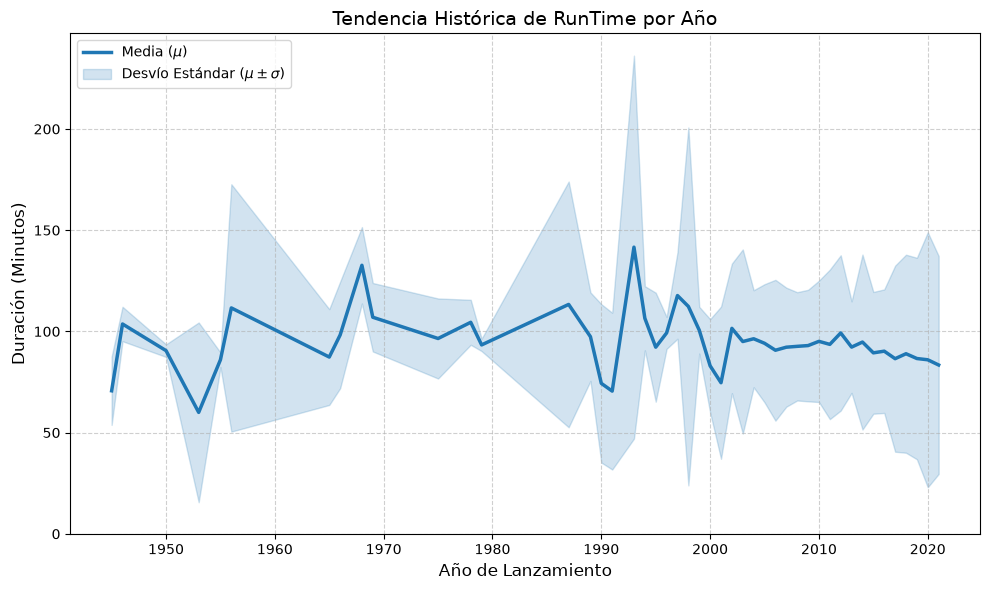

In [208]:
utils.graficar_tendencia_temporal('YEAR_init', 'RunTime', pre_pelis)

<h3>Inciso G

<span style="color:orange">Existe una relacion </span>

In [ ]:
pre_df_f['Genre']

In [214]:
#utils.barras_binarias(['Action', 'Comedy', 'Drama', 'Horror', 'Sci-Fi'], pre_df_f)
pre_g = pre_df_f.groupby('type')['RATING'].median()
pre_g

type
M    6.5
S    7.6
Name: RATING, dtype: float64

In [ ]:
pre_g = 
pre_gpre_df_f[pre_df_f['type'] == 'M'].groupby('Thriller')['RATING'].median()

Thriller
0    6.6
1    5.9
Name: RATING, dtype: float64

In [245]:
pre_df_f['T_H'] = (pre_df_f['GENRE'].str.contains('Thriller')) | (pre_df_f['GENRE'].str.contains('Horror'))
# pre_g = pre_df_f[pre_df_f['YEAR_init'] >= 2020]
# pre_g = pre_g[pre_g['type'] == 'M'].groupby('T_H')['RATING'].median()
pre_g = pre_df_f[pre_df_f['type'] == 'M'].groupby('T_H')['RATING'].median()

pre_g

T_H
False    6.7
True     5.8
Name: RATING, dtype: float64

In [ ]:
pre_df_f.head()

In [248]:
ff = pre_df_f[pre_df_f['YEAR_init'] == 2012]
ff

,MOVIES,YEAR,GENRE,RATING,ONE-LINE,STARS,VOTES,RunTime,Gross,Action,...,Sci-Fi,Short,Sport,Talk-Show,Thriller,War,Western,type,YEAR_init,T_H
68,Line of Duty,(2012– ),"\nCrime, Drama, Mystery",8.7,\nDrama series following the investigations of...,"\n \n Stars:\nMartin Compston, \...","46,751",60.0,NaN,0,...,0,0,0,0,0,0,0,S,2012.0,False
97,Arrow,(2012–2020),"\nAction, Adventure, Crime",7.5,\nSpoiled billionaire playboy Oliver Queen is ...,"\n \n Stars:\nStephen Amell, \nK...","414,712",42.0,NaN,1,...,0,0,0,0,0,0,0,S,2012.0,False
171,The Hobbit: An Unexpected Journey,(2012),"\nAdventure, Fantasy",7.8,"\nA reluctant Hobbit, Bilbo Baggins, sets out ...",\n Director:\nPeter Jackson\n| \n Stars:...,"774,632",169.0,303.0,0,...,0,0,0,0,0,0,0,M,2012.0,False
188,Longmire,(2012–2017),"\nAction, Crime, Drama",8.3,\nWalt Longmire is the dedicated and unflappab...,"\n \n Stars:\nRobert Taylor, \nK...","30,685",60.0,NaN,1,...,0,0,0,0,0,0,0,S,2012.0,False
243,Elementary,(2012–2019),"\nCrime, Drama, Mystery",7.9,\nA modern take on the cases of Sherlock Holme...,"\n \n Stars:\nJonny Lee Miller, ...","103,707",60.0,NaN,0,...,0,0,0,0,0,0,0,S,2012.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7158,Comedians in Cars Getting Coffee,(2012– ),"\nAnimation, Comedy, Family",6.4,\nJerry picks up longtime friend Barry Marder ...,"\n \n Stars:\nJerry Seinfeld, \n...",151,17.0,NaN,0,...,0,0,0,0,0,0,0,S,2012.0,False
7160,Comedians in Cars Getting Coffee,(2012– ),"\nAnimation, Comedy, Family",7.0,"\nIn a 1974 VW Thing, Jerry and his old friend...","\n \n Stars:\nJerry Seinfeld, \n...",162,17.0,NaN,0,...,0,0,0,0,0,0,0,S,2012.0,False
7797,Son,(2012–2013),"\nAdventure, Drama, Mystery",NaN,"\nFeeling guilty over Alev's fate, Ali decides...",\n Director:\nUluç Bayraktar\n| \n Stars...,NaN,29.0,NaN,0,...,0,0,0,0,0,0,0,S,2012.0,False
7798,Son,(2012–2013),"\nAdventure, Drama, Mystery",NaN,"\nAs Taner turns up the heat, Ali faces a dile...",\n Director:\nUluç Bayraktar\n| \n Stars...,NaN,29.0,NaN,0,...,0,0,0,0,0,0,0,S,2012.0,False
